In [80]:
import numpy as np
import numpy.typing as npt
import networkx as nx
import matplotlib.pyplot as plt
import casadi as ca
from copy import deepcopy
from numpy.linalg import inv
import time

In [2]:
## constants
# gravitational constant
g = 9.81  # m/s^2
# wave speed
a = 1.0e3  # m/s
# density
rho = 998.2  # kg/m^3
# dynamic viscosity
mu = 1.002e-3  # Ns/m^2

In [3]:
## average operating conditions
# volume flow
q_mean = 0.0001  # 0224331792911098  # m^3/2
# pump speed
omega_mean = 36.410179219931635  # 35.35520636739956  # 9.7996642  # Hz
omega_max = 74.166667
omega_mean_relative = omega_mean / 74.166667  # dimensionless
mean_pump_pressure = 25274.0257666655

In [4]:
internal_nodes = {
    "pump_inlet": {
        "name": "pump_inlet",
        "node_type": "Junction",
        "elevation": 0.33,
        "demand": 0,
    },
    "pump_outlet": {
        "name": "pump_outlet",
        "node_type": "Junction",
        "elevation": 0.47,
        "demand": 0,
    },
    "tank_inlet": {
        "name": "tank_inlet",
        "node_type": "Tank",
        "elevation": 2.12,
        "area": 1e3,
        "initial_level": 0.0,
        "max_level": 100,
        "demand": 0.000,  # 0.0001 # 0224331792911098
    },
    "tank_outlet": {
        "name": "tank_outlet",
        "node_type": "Tank",
        "elevation": 1.2,
        "area": 0.0254,  # guess
        "initial_level": 0.2,
        "max_level": 2,
        "demand": 0.000,  # 0.0001 # 0224331792911098
    },
    "consumer_valve_inlet": {
        "name": "consumer_valve_inlet",
        "node_type": "Junction",
        "elevation": 0.875,
        "demand": 0,
    },
    "consumer_valve_outlet": {
        "name": "consumer_valve_outlet",
        "node_type": "Junction",
        "elevation": 0.875,
        "demand": 0,
    },
}

reservoirs = {
    "reservoir_1": {
        "name": "reservoir_1",
        "elevation": 0.56,
        "pressure": 0.3833,
    },
    "reservoir_2": {
        "name": "reservoir_2",
        "elevation": 0.56,
        "pressure": 0.3833,
    },
}


pipes = {
    "pump_suction_pipe": {
        "start_node": "reservoir_1",
        "end_node": "pump_inlet",
        "type": "pipe",
        "length": 2.25,
        "diameter": 0.015,
        "roughness": 0.02,  # 0.007e-3,
        # "friction_factor": 3.383e-3,  # 2.65e-1,
    },
    "tank_feeding_pipe": {
        "start_node": "pump_outlet",
        "end_node": "tank_inlet",
        "type": "pipe",
        "length": 5,
        "diameter": 0.015,
        "roughness": 0.02,  # 0.007e-3,
        # "friction_factor": 4.4e-3,  # 1.1357142e-1,
    },
    "tank_outlet_pipe": {
        "start_node": "tank_outlet",
        "end_node": "consumer_valve_inlet",
        "type": "pipe",
        "length": 1.7,
        "diameter": 0.015,
        "roughness": 0.02,  # 0.007e0,
        # "friction_factor": 3.383e-3,  # 2.65e-1,
    },
    # "valve_pipe": {
    #     "start_node": "consumer_valve_inlet",
    #     "end_node": "consumer_valve_outlet",
    #     "type": "pipe",
    #     "length": 0.1,
    #     "diameter": 0.015,
    #     "roughness": 0.02, # 0.007e-3,
    #     "friction_factor": 1.65e-3,  # 1.325e-1,  # 0.021
    # },
    "consumer_outlet_pipe": {
        "start_node": "consumer_valve_outlet",
        "end_node": "reservoir_2",
        "type": "pipe",
        "length": 0.35,
        "diameter": 0.015,
        "roughness": 0.02,  # 0.007e-3,
        # "friction_factor": 4.4e-3,  # 1.1357142e-1,
    },
}

virtual_pipes = {
    "tank_connecting_pipe": {
        "start_node": "tank_inlet",
        "end_node": "tank_outlet",
        "type": "pipe",
        "length": 1,
        "diameter": 0.015,
        "roughness": 0.02,  # 0.007e-3,
        "friction_factor": 4.4e-3,  # 4.4 # 4.4e-3,  # 1.1357142e-1,
    },
}

pumps = {
    "pump": {
        "start_node": "pump_inlet",
        "end_node": "pump_outlet",
        "type": "pump",
        "diameter": 0.015,
        "length": 0.1,
        "head_coefficients": [
            -1354609.008,
            8.9484863058495,
            0.0019325347775285347,
        ],  # [-0.1045223, 0.18435539, 10.63028341],
        "power_coefficients": [
            -3.24482049,
            7.30651404,
            20.33482845,
            103.00866719,
            7.59352180888483,
        ],
        "system_coefficient": 0.3,  # 0.2,
        "min_speed": 23.33333,
        "max_speed": 74.16667,
        "initial_input": omega_mean,  # 35.35520636739956,
    }
}

valves = {
    "consumer_valve": {
        "start_node": "consumer_valve_inlet",
        "end_node": "consumer_valve_outlet",
        "type": "valve",
        "diameter": 0.015,
        "length": 0.1,
        "system_coefficient": 0.00017671458676442585,  # 0.2,
        "valve_coefficient": 0.4450007250059065,  # 3.1785766071850463,  # 6.357153214370093,  # 6.357154550561105, #6.357154551,# 2.9277, 6.357153214370093
        "initial_input": 0.5,
    },
}

In [44]:
class EWCMDESystem:
    def __init__(self, A=None, B=None, C=None, E=None, F=None):
        self.A = A
        self.B = B
        self.C = C
        self.E = E
        self.F = F
        pass

    def construct_from_json(
        self, internal_nodes, reservoirs, pipes, virtual_pipes, pumps, valves
    ):
        self.internal_nodes = internal_nodes
        self.reservoirs = reservoirs
        self.pipes = pipes
        self.virtual_pipes = virtual_pipes
        self.pumps = pumps
        self.valves = valves

        self.alg_vars = dict(self.virtual_pipes)
        self.alg_vars.update(self.pumps)
        self.alg_vars.update(self.valves)

        self.elements = dict(self.pumps)
        self.elements.update(self.valves)

        self.internal_node_list = list(self.internal_nodes.keys())
        self.reservoir_list = list(self.reservoirs.keys())

        self.pipe_list = list(self.pipes.keys())
        self.alg_var_list = list(self.alg_vars.keys())
        self.virtual_pipe_list = list(self.virtual_pipes.keys())
        self.pump_list = list(self.pumps.keys())
        self.valve_list = list(self.valves.keys())

        self.pipe_dict = {
            (pipe["start_node"], pipe["end_node"]): pipe_name
            for pipe_name, pipe in self.pipes.items()
        }

        self.alg_var_dict = {
            (
                alg_var["start_node"],
                alg_var["end_node"],
            ): alg_var_name
            for alg_var_name, alg_var in self.alg_vars.items()
        }

        self.edge_dict = deepcopy(self.pipe_dict)
        self.edge_dict.update(self.alg_var_dict)

        dG = nx.DiGraph()
        dG.add_nodes_from(self.reservoirs.keys())
        dG.add_nodes_from(self.internal_nodes.keys())
        dG.add_edges_from(self.edge_dict.keys())

        self.A_p = -nx.incidence_matrix(
            dG,
            nodelist=self.internal_node_list + self.reservoir_list,
            edgelist=self.pipe_dict.keys(),
            oriented=True,
        )

        self.A_e = -nx.incidence_matrix(
            dG,
            nodelist=self.internal_node_list + self.reservoir_list,
            edgelist=self.alg_var_dict.keys(),
            oriented=True,
        )

        self.A_I_p = self.A_p[: len(self.internal_node_list)]
        self.A_I_e = self.A_e[: len(self.internal_node_list)]

        self.A_R_p = self.A_p[-len(self.reservoir_list) :]
        self.A_R_e = self.A_e[-len(self.reservoir_list) :]

        # L,R,C matrices
        self.L = []  # inductance
        self.R = []  # resistance
        self.NC = []  # node capacitance
        self.TC = []  # tank capactitance
        for pipe in pipes.values():
            cross_section_area = np.pi * (pipe["diameter"] / 2) ** 2
            self.L.append(pipe["length"] / (g * cross_section_area))
            self.R.append(
                8
                * pipe["length"]
                * pipe["roughness"]
                / (np.pi**2 * g * pipe["diameter"] ** 5)
            )
            self.NC.append(
                (2 * g * np.pi / 4 * pipe["diameter"] ** 2 * pipe["length"]) / (a**2)
            )

        for node in internal_nodes.values():
            if node["node_type"] == "Tank":
                self.TC.append(node["area"])
            else:
                self.TC.append(0.0)

        for alg_var in self.alg_vars.values():
            self.NC.append(
                (2 * g * np.pi / 4 * alg_var["diameter"] ** 2 * alg_var["length"])
                / (a**2)
            )

        self.L = np.diag(self.L)
        self.R = np.diag(self.R)

        self.L_inv = inv(self.L)
        self.L_inv_R = self.L_inv @ self.R

        self.G = inv(
            np.diag(
                1
                / 2
                * np.abs(np.block([self.A_I_p.todense(), self.A_I_e.todense()]))
                @ self.NC
                + self.TC
            )
        )

        self.D = np.diag(
            [element["system_coefficient"] for element in self.elements.values()]
        )

        self.D_v = self.D[
            -len(self.valve_list) :,
            -len(self.valve_list) :,
        ]

        self.pump_coeffs_0 = []
        self.pump_coeffs_1 = []
        self.pump_coeffs_2 = []
        for pump in self.pumps.values():
            pump_coeffs = pump["head_coefficients"]
            self.pump_coeffs_0.append(pump_coeffs[0])
            self.pump_coeffs_1.append(pump_coeffs[1])
            self.pump_coeffs_2.append(pump_coeffs[2])

        self.c_d = []
        for valve in self.valves.values():
            self.c_d.append(valve["valve_coefficient"])

        self.state_dict = {
            "q_p": self.pipe_list,
            "q_e": self.alg_var_list,
            "h_I": self.internal_node_list,
            "z": self.pump_list + self.valve_list,
        }

        self.input_dict = {
            "h_R": self.reservoir_list,
            "Q": self.internal_node_list,
            "u_e": self.pump_list + self.valve_list,
        }

    def set_up_DAE(self):
        n = len(self.state_dict["q_p"])
        m = len(self.state_dict["h_I"])
        l = len(self.state_dict["q_e"])
        lz = len(self.state_dict["q_e"]) - len(self.virtual_pipe_list)
        r = len(self.reservoir_list)

        # state vector
        self.q_p = ca.vertcat(
            *[ca.MX.sym(f"q_p_{svn}") for svn in self.state_dict["q_p"]]
        )
        self.h_I = ca.vertcat(
            *[ca.MX.sym(f"h_I_{svn}") for svn in self.state_dict["h_I"]]
        )
        # self.z_vp = ca.vertcat(
        #     *[ca.MX.sym(f"z_vp_{svn}") for svn in self.virtual_pipe_list]
        # )
        self.z_p = ca.vertcat(*[ca.MX.sym(f"z_p_{svn}") for svn in self.pump_list])
        self.z_v = ca.vertcat(*[ca.MX.sym(f"z_v_{svn}") for svn in self.valve_list])
        self.z = ca.vertcat(self.z_p, self.z_v)

        self.x = ca.vertcat(self.q_p, self.h_I, self.z)

        # algebraic state vector
        self.q_e_vp = ca.vertcat(
            *[ca.MX.sym(f"q_e_vp_{svn}") for svn in self.virtual_pipe_list]
        )
        self.q_e_p = ca.vertcat(*[ca.MX.sym(f"q_e_p_{svn}") for svn in self.pump_list])
        self.q_e_v = ca.vertcat(*[ca.MX.sym(f"q_e_v_{svn}") for svn in self.valve_list])

        self.q_e = ca.vertcat(self.q_e_vp, self.q_e_p, self.q_e_v)
        self.ax = self.q_e

        # control input vector
        self.h_R = ca.vertcat(
            *[ca.MX.sym(f"h_R_{svn}") for svn in self.input_dict["h_R"]]
        )
        self.Q = ca.vertcat(*[ca.MX.sym(f"Q_{svn}") for svn in self.input_dict["Q"]])
        self.u_e = ca.vertcat(
            *[ca.MX.sym(f"u_e_{svn}") for svn in self.input_dict["u_e"]]
        )

        self.u = ca.vertcat(self.h_R, self.Q, self.u_e)

        # system matrices
        self.A = np.block(
            [
                [
                    np.zeros(shape=(n, n)),
                    self.L_inv @ self.A_I_p.T,
                    np.zeros(shape=(n, lz)),
                ],
                [-self.G @ self.A_I_p, np.zeros(shape=(m, m)), np.zeros(shape=(m, lz))],
                [
                    np.zeros(shape=(lz, n)),
                    np.zeros(shape=(lz, m)),
                    -self.D,
                ],
            ]
        )
        self.EL = np.block(
            [
                [np.zeros(shape=(n, l))],
                [-self.G @ self.A_I_e],
                [np.zeros(shape=(lz, l))],
            ]
        )
        self.F = ca.blockcat(
            [
                # [self.L_inv_R @ ca.diag(ca.fabs(self.q_p)) @ self.q_p],
                [self.L_inv_R @ ca.diag(self.q_p) @ ca.fabs(self.q_p)],
                [np.zeros(shape=(m, 1))],
                [np.zeros(shape=(lz, 1))],
            ]
        )

        self.B = np.block(
            [
                [
                    self.L_inv @ self.A_R_p.T,
                    np.zeros(shape=(n, m)),
                    np.zeros(shape=(n, lz)),
                ],
                [np.zeros(shape=(m, r)), -self.G, np.zeros(shape=(m, lz))],
                [np.zeros(shape=(lz, r)), np.zeros(shape=(lz, m)), self.D],
            ]
        )

        self.aF = ca.vertcat(
            -(
                np.diag(self.pump_coeffs_0)
                @ (ca.diag(self.q_e_p) @ ca.diag(self.q_e_p))
                + np.diag(self.pump_coeffs_1)
                @ (ca.diag(self.q_e_p) @ ca.diag(self.z_p))
                + np.diag(self.pump_coeffs_2) @ (ca.diag(self.z_p) @ ca.diag(self.z_p))
            ),
            (
                (1 / (2 * 9.81))
                * (inv(np.diag(self.c_d) @ self.D_v)) ** 2
                * (ca.diag(self.q_e_v) @ ca.inv(ca.diag(self.z_v))) ** 2
            ),
        )

        # set up state equation
        self.x_dot = self.A @ self.x + self.EL @ self.q_e - self.F + self.B @ self.u

        # set up algebraic equation
        self.alg_eq = ca.vertcat(
            (self.q_p[1] - self.q_e[0]),
            (
                self.A_I_e.todense().T[1:] @ self.h_I
                - self.aF
                + self.A_R_e.todense().T[1:] @ self.h_R
            ),
        )

    def set_up_initial_values(self, q_p_0, h_I_0, z_0, q_e_0):
        self.q_p_0 = [q_p_0[i] for i in self.state_dict["q_p"]]
        self.h_I_0 = [h_I_0[i] for i in self.state_dict["h_I"]]
        self.z_0 = [z_0[i] for i in self.state_dict["z"]]
        self.q_e_0 = [q_e_0[i] for i in self.state_dict["q_e"]]

        x0 = np.concatenate([self.q_p_0, self.h_I_0, self.z_0])
        self.x0 = ca.DM(x0)
        self.ax0 = ca.DM(self.q_e_0)

    def simulate_state(self, u, t0=0, t_stop=2, dt=1e-4, x0=None, ax0=None):
        if x0 is not None:
            self.x0 = x0
        if ax0 is not None:
            self.ax0 = ax0

        t = np.arange(t0, t_stop, dt)

        dae = {
            "x": self.x,
            "z": self.ax,
            "p": self.u,
            "ode": self.x_dot,
            "alg": self.alg_eq,
        }
        # opts = {
        #     "tf": 1e-4,  # time step for each integrator call
        #     #     "abstol": 1e-8,
        #     #     "reltol": 1e-8,
        # }

        Fint = ca.integrator(
            "Fint",
            "collocation",  # "idas",
            dae,
            t0,
            dt,
            {
                # "calc_ic": True,
                # "calc_icB": True,
                # "abstol": 1e-8,
                # "reltol": 1e-4,
                # "max_num_steps": 5000,
                # "max_order": 5,  # BDF order cap
                # "max_step_size": dt / 2,  # important for control problems
                # "linear_solver": "csparse",
                "collocation_scheme": "radau",
                "number_of_finite_elements": 1,
                "interpolation_order": 1,  # 3 or 5 typical
                "rootfinder": "newton",
                "rootfinder_options": {"abstol": 1e-10, "max_iter": 20},
            },
        )

        # initial conditions
        x0 = ca.DM(self.x0)
        z0 = ca.DM(self.ax0)

        nx = x0.numel()
        nz = z0.numel()
        nt = len(t)

        x_vals = np.empty((nt, nx))
        ax_vals = np.empty((nt, nz))

        xt = deepcopy(self.x0)
        axt = deepcopy(self.ax0)

        x_vals[0, :] = np.asarray(xt).ravel(order="F")
        ax_vals[0, :] = np.asarray(axt).ravel(order="F")

        for i in range(1, nt):
            res = Fint(x0=xt, z0=axt, p=u[i])
            xt = res["xf"]
            axt = res["zf"]
            x_vals[i, :] = np.asarray(xt).ravel(order="F")
            ax_vals[i, :] = np.asarray(axt).ravel(order="F")
        return x_vals, ax_vals


In [45]:
np.array([*[1e-6] * 6 + [1e-10] * 2])

array([1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-10, 1.e-10])

In [46]:
q_p_0 = {
    "pump_suction_pipe": 0.0001,
    "tank_feeding_pipe": 0.0001,
    "tank_outlet_pipe": 0.0001,
    "consumer_outlet_pipe": 0.0001,
}
h_I_0 = {
    "pump_inlet": 0.9432828625777657,
    "pump_outlet": (25274.0257666655 / (rho * g)) + 0.9432828625777657,
    "tank_inlet": 3.524243866935379 - 0.2,
    "tank_outlet": 1.4,
    "consumer_valve_inlet": 1.3630049297801217,
    "consumer_valve_outlet": 1.033323297127033,
}
z_0 = {
    "pump": 36.410179219931635,
    "consumer_valve": 0.5,
}

q_e_0 = {
    "tank_connecting_pipe": 0.0001,
    "pump": 0.0001,
    "consumer_valve": 0.0001,
}

In [81]:
sys = EWCMDESystem()
sys.construct_from_json(internal_nodes, reservoirs, pipes, virtual_pipes, pumps, valves)
sys.set_up_DAE()
sys.set_up_initial_values(q_p_0, h_I_0, z_0, q_e_0)

t0 = 0
t_stop = 1
dt = 1e-3
nt = round((t_stop - t0) / dt)

t_3 = np.arange(t0, t_stop, dt)

u_h_R = (
    np.diag([r["elevation"] + r["pressure"] for r in reservoirs.values()])
    @ np.ones((len(reservoirs), nt))
).T

u_Q = (
    np.diag([node["demand"] for node in internal_nodes.values()])
    @ np.ones((len(internal_nodes), nt))
).T

u_u_e = (
    np.diag([el["initial_input"] for el in sys.elements.values()])
    @ np.ones((len(sys.elements.values()), nt))
).T

u = np.concatenate([u_h_R, u_Q, u_u_e], axis=1)

start = time.time()
x_vals_3, ax_vals_3 = sys.simulate_state(u, t0=t0, t_stop=t_stop, dt=dt)
end = time.time()
time_elapsed_3 = end - start

In [82]:
sys = EWCMDESystem()
sys.construct_from_json(internal_nodes, reservoirs, pipes, virtual_pipes, pumps, valves)
sys.set_up_DAE()
sys.set_up_initial_values(q_p_0, h_I_0, z_0, q_e_0)

t0 = 0
t_stop = 1
dt = 1e-4
nt = round((t_stop - t0) / dt)

t_4 = np.arange(t0, t_stop, dt)

u_h_R = (
    np.diag([r["elevation"] + r["pressure"] for r in reservoirs.values()])
    @ np.ones((len(reservoirs), nt))
).T

u_Q = (
    np.diag([node["demand"] for node in internal_nodes.values()])
    @ np.ones((len(internal_nodes), nt))
).T

u_u_e = (
    np.diag([el["initial_input"] for el in sys.elements.values()])
    @ np.ones((len(sys.elements.values()), nt))
).T

u = np.concatenate([u_h_R, u_Q, u_u_e], axis=1)

start = time.time()
x_vals_4, ax_vals_4 = sys.simulate_state(u, t0=t0, t_stop=t_stop, dt=dt)
end = time.time()
time_elapsed_4 = end - start

In [83]:
sys = EWCMDESystem()
sys.construct_from_json(internal_nodes, reservoirs, pipes, virtual_pipes, pumps, valves)
sys.set_up_DAE()
sys.set_up_initial_values(q_p_0, h_I_0, z_0, q_e_0)

t0 = 0
t_stop = 1
dt = 1e-5
nt = round((t_stop - t0) / dt)

t_5 = np.arange(t0, t_stop, dt)

u_h_R = (
    np.diag([r["elevation"] + r["pressure"] for r in reservoirs.values()])
    @ np.ones((len(reservoirs), nt))
).T

u_Q = (
    np.diag([node["demand"] for node in internal_nodes.values()])
    @ np.ones((len(internal_nodes), nt))
).T

u_u_e = (
    np.diag([el["initial_input"] for el in sys.elements.values()])
    @ np.ones((len(sys.elements.values()), nt))
).T

u = np.concatenate([u_h_R, u_Q, u_u_e], axis=1)

start = time.time()
x_vals_5, ax_vals_5 = sys.simulate_state(u, t0=t0, t_stop=t_stop, dt=dt)
end = time.time()
time_elapsed_5 = end - start

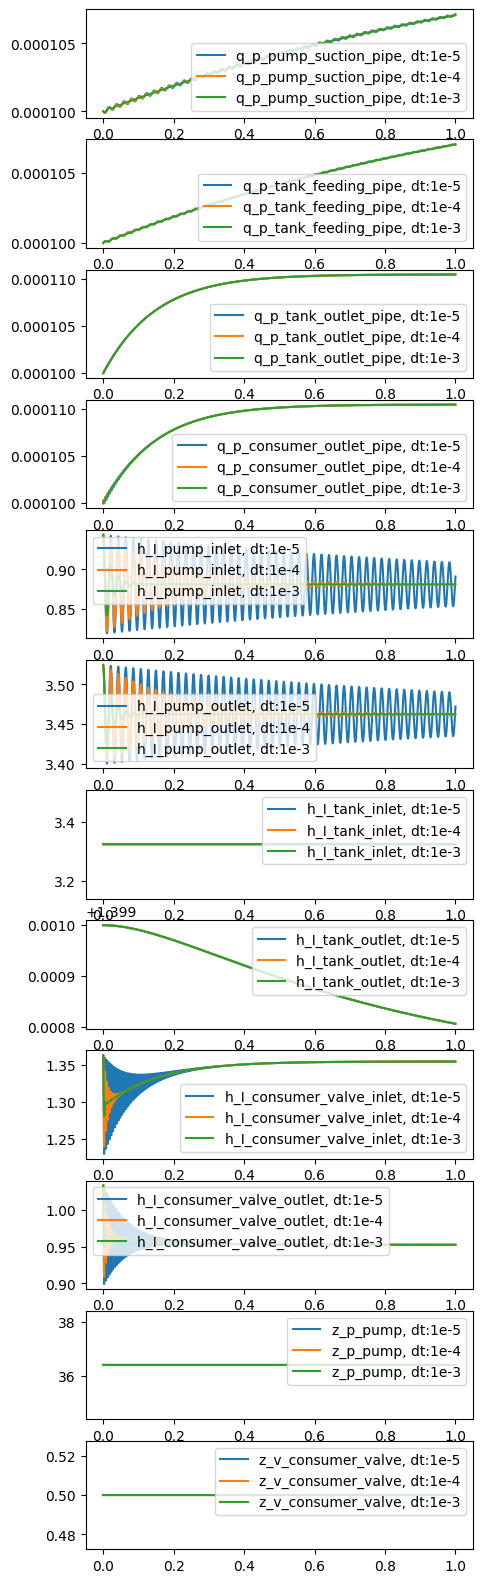

In [ ]:
fig, axs = plt.subplots(sys.x.shape[0], figsize=(5, 20))
t = np.arange(t0, t_stop, dt)

for i in range(sys.x.shape[0]):
    axs[i].plot(t_5[:], x_vals_5[:, i], label=sys.x[i].name() + ", dt:1e-5")
    axs[i].plot(t_4[:], x_vals_4[:, i], label=sys.x[i].name() + ", dt:1e-4")
    axs[i].plot(t_3[:], x_vals_3[:, i], label=sys.x[i].name() + ", dt:1e-3")

    axs[i].legend()

plt.tight_layout()

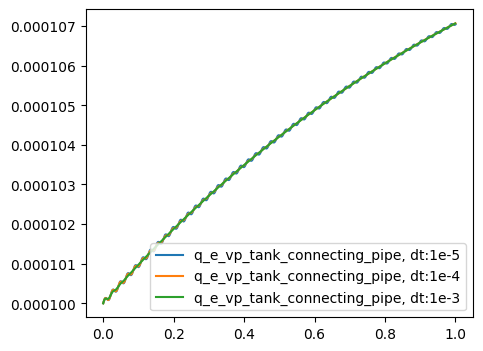

In [86]:
fig, axs = plt.subplots(1, figsize=(5, 4))
t = np.arange(t0, t_stop, dt)

for i in range(1):
    axs.plot(t_5[:], ax_vals_5[:, i], label=sys.ax[i].name() + ", dt:1e-5")
    axs.plot(t_4[:], ax_vals_4[:, i], label=sys.ax[i].name() + ", dt:1e-4")
    axs.plot(t_3[:], ax_vals_3[:, i], label=sys.ax[i].name() + ", dt:1e-3")
    axs.legend()

<BarContainer object of 3 artists>

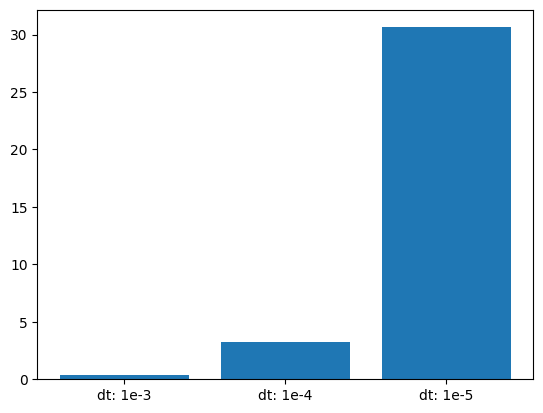

In [85]:
plt.bar(
    ["dt: 1e-3", "dt: 1e-4", "dt: 1e-5"],
    [time_elapsed_3, time_elapsed_4, time_elapsed_5],
)